# TS3

#### Rey Tomás 
#### APS

# Introducción 

Calcular la FFT de una señal significa multiplicarla en el tiempo por una caja del mismo tamaño que la señal, o, lo que es lo mismo, convolucionarla en el tiempo con una sinc. En el caso de una senoidal, esta tendrá la forma

$$x_n=sen(f_0t) (1)$$

Donde la frecuencia de la señal senoidal se relaciona con la frecuencia de muestreo según la relación:

$$f_0=k_0\frac{f_s}{N}=k_0.\triangle f(2)$$

Recordando que $\triangle f$ es la frecuencia de sampleo de la FFT, se observa que la relación entre la frecuencia con la que la FFT toma datos y aquella con la que la senoidal es emitida es una constante $k_0$. En este trabajo se analizará que sucede cuando $k_0$ es o no es un múltiplo exacto de $\triangle f$. La potencia de las señales en este TP serán normalizadas o trabajadas en dB.

El zero padding es una técnica que consiste en añadir artificialmente ceros al final de la señal original. El efecto de esto es reducir la frecuencia de muestreo, ya que de la ecuación (2) podemos ver que:

$$\frac{f_s}{N}=\triangle f(3)$$

Ahora, debido al zero padding, si agregamos nueve N´s de ceros al final tendremos una señal de longitud M=10N, por lo que según (3), $\triangle f$ se reduce. Se puede pensar como una "lupa" que le permite a la FFT tomar más puntos.

In [34]:
"""
Created on Wed Sep  9 13:58:21 2026

@author: tomas
"""

'\nCreated on Wed Sep  9 13:58:21 2026\n\n@author: tomas\n'

In [35]:
# -*- coding: utf-8 -*-
"""
Created on Thu Sep  3 18:44:24 2026

@author: tomas
"""
import numpy as np

In [36]:
import matplotlib.pyplot as plt

In [37]:
N=1000
fs=1000
delta_f=fs/N
n=np.arange(0,N)/fs
A=np.sqrt(2) #para normalizar

In [38]:
frec=np.arange(0,fs,delta_f)

a)

In [39]:
k0=N/4
x_n=A*np.sin(k0*2*np.pi*delta_f*n)
X_k=np.abs(np.fft.fft(x_n))
psd=(X_k**2)/N**2

k02=N/4+1/4
x_n_2=A*np.sin(k02*2*np.pi*delta_f*n)
X_k_2=np.abs(np.fft.fft(x_n_2))
psd2=(X_k_2**2)/N**2

k03=N/4+1/2
x_n_3=A*np.sin(k03*2*np.pi*delta_f*n)
X_k_3=np.abs(np.fft.fft(x_n_3))
psd3=(X_k_3**2)/N**2

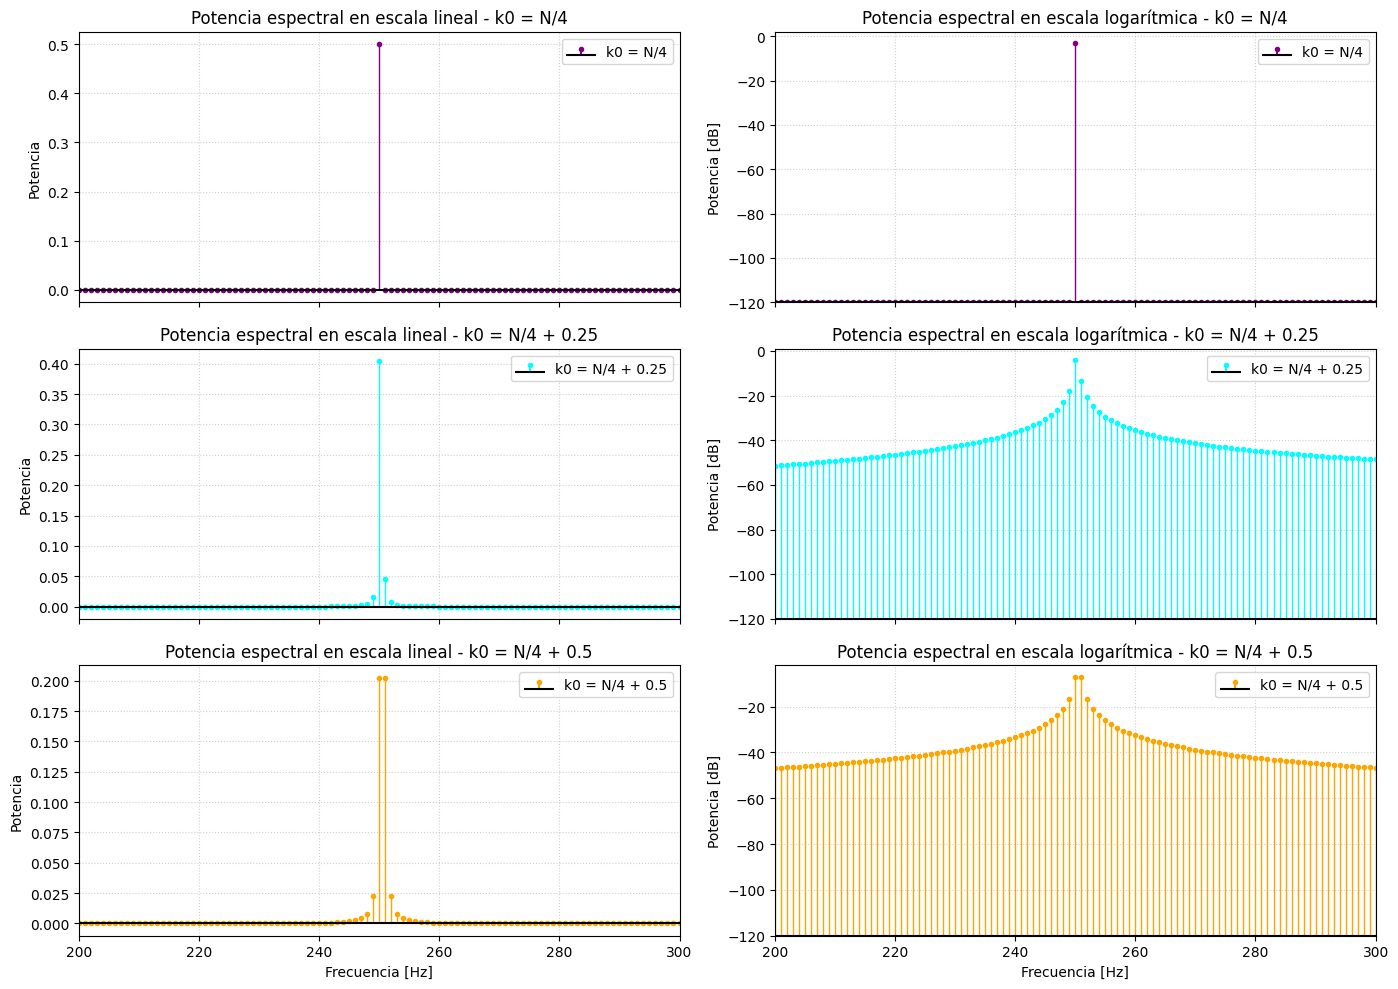

In [40]:
import matplotlib.pyplot as plt
import numpy as np

fig, axs = plt.subplots(3, 2, figsize=(14, 10), sharex=True)

# Señales y configuraciones 
psds = [psd, psd2, psd3]
titulos = ['k0 = N/4', 'k0 = N/4 + 0.25', 'k0 = N/4 + 0.5']
colores = ['purple', 'cyan', 'orange']

# Piso de referencia para la escala en dB
piso_db = -120

for i in range(3):
    # Columna izquierda: Escala lineal
    marker_lin, stem_lin, base_lin = axs[i, 0].stem(
        frec, psds[i], 
        linefmt=colores[i], 
        markerfmt='o', 
        basefmt='k-', 
        label=titulos[i]
    )
    plt.setp(marker_lin, markersize=3, color=colores[i])
    plt.setp(stem_lin, linewidth=1)
    
    axs[i, 0].set_title(f'Potencia espectral en escala lineal - {titulos[i]}')
    axs[i, 0].set_ylabel('Potencia')
    axs[i, 0].set_xlim(0, fs / 2)
    axs[i, 0].grid(True, linestyle=':', alpha=0.6)
    axs[i, 0].legend()

    # Columna derecha: Escala en dB
    psd_db = 10 * np.log10(np.maximum(psds[i], 1e-12))
    
    marker_db, stem_db, base_db = axs[i, 1].stem(
        frec, psd_db, 
        bottom=piso_db,           
        linefmt=colores[i], 
        markerfmt='o', 
        basefmt='k-', 
        label=titulos[i]
    )
    plt.setp(marker_db, markersize=3, color=colores[i])
    plt.setp(stem_db, linewidth=1)
    
    axs[i, 1].set_ylim(piso_db, max(psd_db) + 5)
    axs[i, 1].set_title(f'Potencia espectral en escala logarítmica - {titulos[i]}')
    axs[i, 1].set_ylabel('Potencia [dB]')
    axs[i, 1].grid(True, linestyle=':', alpha=0.6)
    axs[i, 1].legend()

axs[2, 0].set_xlabel('Frecuencia [Hz]')
axs[2, 1].set_xlabel('Frecuencia [Hz]')

plt.tight_layout()
plt.xlim(200,300)
plt.show()

En estos gráficos se aprecia el efecto de desparramo espectral o spectral leakage cuando la frecuencia de la senoidal no cae exactamente sobre los bins en los que la señal es leída. Lo que se está haciendo es multiplicar una señal senoidal por una caja de tamaño N, lo que significa convolusionar en frecuencia una delta (senoidal) con una sinc (caja cuadrada de tamaño N).

En k0=N/4 se observa una sintonía perfecta, debido a que k0 es un multiplo de $\triangle$f, según la ecuación (3), entonces la sinc está centrada en f=250 hz, y dado que la FFT solo "ve" lo que está pasando cada múltiplos de $\triangle$f, lo único que consigue leer son los 0 de la sinc, por eso toda la potencia espectral está en un solo punto. El gráfico en escala logarítmica muestra principalmmente lo mismo. 

En k0=N/4+0.25 se empieza a ver el desparrame espectral. A diferencia del caso anterior, ahora la sinc no está perfectamente centrada en f=250hz, sino que está ligeramente corrido de ese centro. Ahora, no solo que la potencia en 250hz se vio diminuída debido a su desparrame (se puede ver una caída de 0,10 en la potencia normalizada respecto al gráfico anterior) sino que también ahora los lóbulos de la sinc ya no caen exactamente en un 0. Debido a la forma de una sinc, sin embargo, cuánto más me alejo del lóbulo principal, menor es la amplitud de cada lóbulo, por lo que apenas luego de 3 bins la potencia ya aparenta ser casi 0 nuevamente. En este caso, la escala logarítmica se vuelve más interesante ya que muestra como, si bien la potencia en dB fuera del centro de la sinc sigue siendo muy baja, ya no es exactamente 0 como se muestra en el gráfico en dB para k0=N-4.

En k0=N/4+0.5, se continua denotando el efecto descripto de manera incluso más evidente. La potencia espectral normalizada se redujo a menos de la mitad de la señal original, e incluso se llegan a apreciar dos bins con potencia de alrededor 0,20 que son ambas pertenecientes al lóbulo principal, mientras que en el resto la FFT leyó valores más altos de los lóbulos secundarios. En este caso, la señal tardó más bins en volver a hacerse 0 y el gráfico de potencia en dB muestra que los valoers cercanos a 0 son de potencia similar en dB respecto al gráfico anterior.

#### ACLARACIÓN: los gráficos fueron limitados en un rango de 200 a 300 hz para que se visualizara mejor lo que está pasando ya que en el resto de frecuencias la potencia es cercana a 0

b

In [41]:
potencia1=np.sum(psd)
print(potencia1)
potencia2=np.sum(psd2)
print(potencia2)
potencia3=np.sum(psd3)
print(potencia3)
#repetir en tiempo
potencia1_t=np.sum(x_n**2)/N
print(potencia1_t)
potencia2_t=np.sum(x_n_2**2)/N
print(potencia2_t)
potencia3_t=np.sum(x_n_3**2)/N
print(potencia3_t)

1.0000000000000002
0.9989999999999997
1.0000000000000007
1.0000000000000002
0.9989999999999998
1.0000000000000004


c

In [42]:
ceros=np.zeros(9*N)

In [43]:
#k0=N/4
x_zp=np.concatenate([x_n,ceros])
delta_f_zp=fs/(10*N)

In [44]:
n_zp=np.arange(0,10*N)/fs
frec=np.arange(0,fs,delta_f_zp)

In [81]:
import matplotlib.pyplot as plt
import numpy as np

def func_c(x_zp, frec, n_zp, k0):
    X_k_zp = np.abs(np.fft.fft(x_zp))
    psd_zp = (X_k_zp**2) / (10 * N)**2
    
    #Lineal
    plt.figure(figsize=(10, 4))
    marker_lin, stem_lin, base_lin = plt.stem(frec, psd_zp, linefmt='b-', markerfmt='bo', basefmt='k-')
    plt.setp(marker_lin, markersize=1)   # Marcadores chicos para no saturar
    plt.setp(stem_lin, linewidth=0.7)
    
    plt.title(f'Zero Padding con 9*N ceros al final para k0={k0}')
    plt.xlabel('Frecuencia [Hz]')
    plt.ylabel('Potencia [veces]')
    plt.xlim(240, 260)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.show()
    
    #Logarítmica
    piso_db = -80 
    psd_db = 10 * np.log10(np.maximum(psd_zp, 1e-12))
    
    plt.figure(figsize=(10, 4))
    marker_db, stem_db, base_db = plt.stem(frec, psd_db, bottom=piso_db, linefmt='r-', markerfmt='ro', basefmt='k-')
    plt.setp(marker_db, markersize=2)
    plt.setp(stem_db, linewidth=0.7)
    
    plt.title(f'Zero Padding con 9*N ceros al final para k0={k0} (dB)')
    plt.xlabel('Frecuencia [Hz]')
    plt.ylabel('Potencia [dB]')
    plt.xlim(200, 300)
    plt.ylim(piso_db, np.max(psd_db) + 5)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.show()

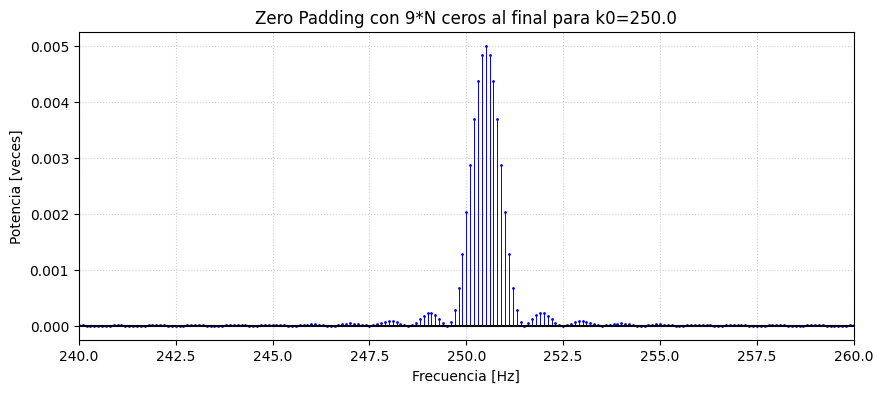

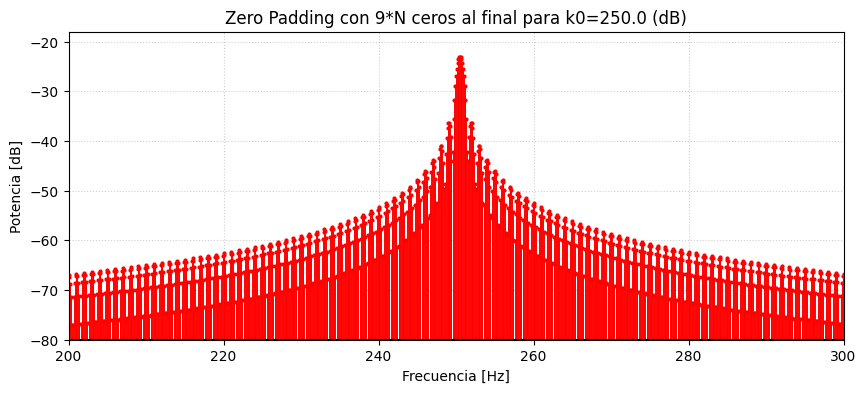

In [82]:
func_c(x_zp,frec,n_zp,k0)

k0=n/4+1/4

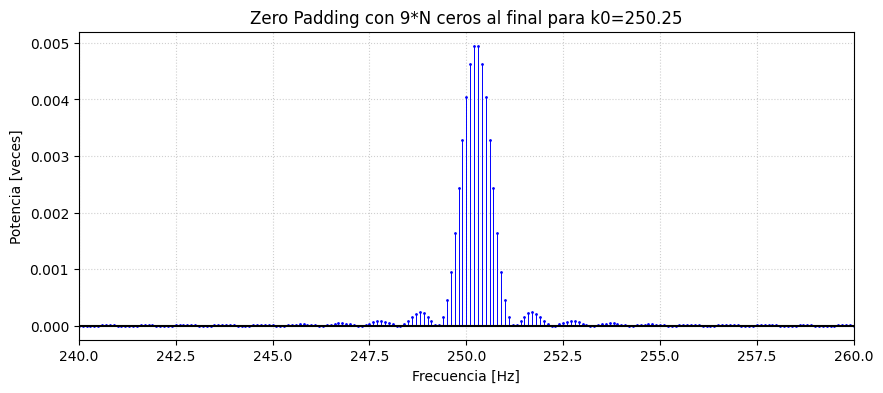

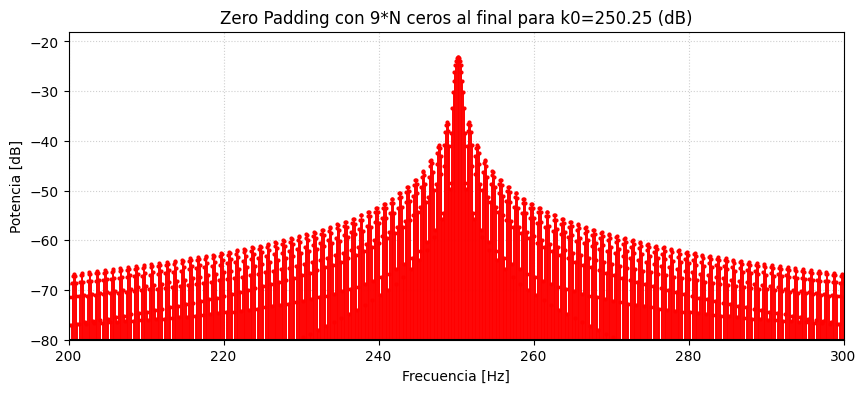

In [83]:
x_zp=np.concatenate([x_n_2,ceros])
func_c(x_zp,frec,n_zp,k02)

k0=n/4+1/2

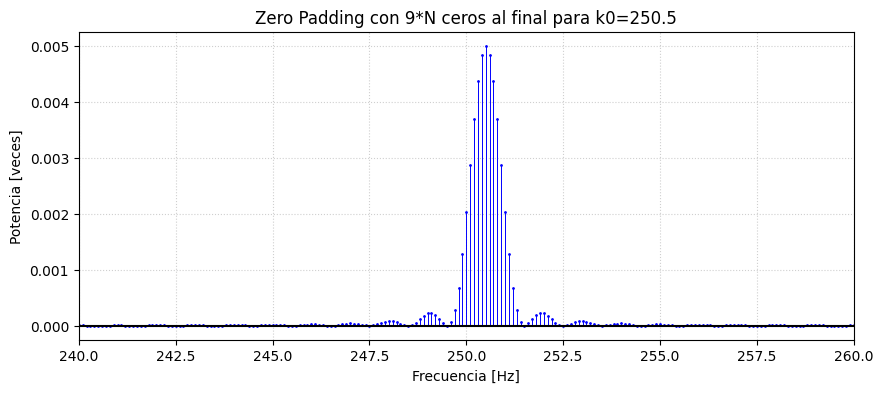

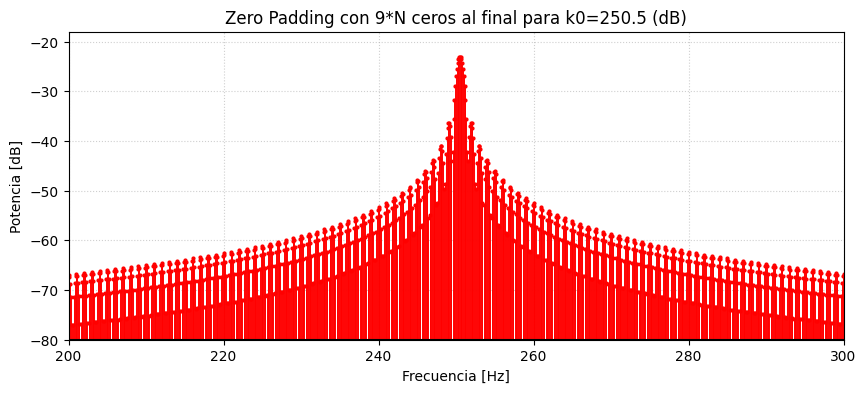

In [84]:
x_zp=np.concatenate([x_n_3,ceros])
func_c(x_zp,frec,n_zp,k03)

Como se predijo en la introducción, el zero padding hizo las veces de "lupa" y permitió ver más a detalle el comportamiento real de la sinc convolucionada con una senoidal donde la frecuencia de la señal es un múltiplo entero de la frecuencia de muestreo. Lo que antes se veía como un punto que representaba el pico de la sinc, ahora se ve como una señal sinc mucho más detallada , e incluso se puede ver como el pico no está centrado en exáctamente N/4, y como toma valores cercanos a 0 luego del tercer lóbulo secundario sin llegar a serlo. 

Para los 3 $k_0$ evaluados, el gráfico se vio exáctamente igual, demostrando que en la parte a) el problema era que para pequeños corrimientos de la relación entre la frecuencia de señal y muestreo, no había un bin cerca del cual caer.

# Conclusiones

El desparrame espectral depende de la sintonía con la resolución espectral. Si el $k_0$ no es un múltiplo, entonces la FFT no capta los ceros de la sinc alrededor de N/4 y toma en su lugar distorsiones.

La escala logarítmica muestra de mejor manera como decae la señal con el tiempo, a diferencia de la lineal.

Aplicarle un zero padding a una señal reduce la frecuencia de sampleado que permite ver más en detalle la convolución de la señal. Esto permite vislumbrar que la señal sinc está presente en todo momento, solo que la FFT no logra siempre mostrarla con fidelidad, y en el caso en el que no hubo zero padding la potencia espectral fue asignada mayoritariamente a un bin, mientras que con el zero padding la frecuencia fue distribuida de manera más fiel a como sucedería en una sinc continua.